In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
import sklearn.metrics as metrics
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from google.colab import drive
import zipfile
from torchvision.datasets import ImageFolder
from torchvision import models


In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/data/train.zip -d /content/train
!unzip /content/drive/MyDrive/data/test.zip -d /content/test

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  inflating: /content/test/test/cats/cat.10000.jpg  
  inflating: /content/test/test/cats/cat.10001.jpg  
  inflating: /content/test/test/cats/cat.10007.jpg  
  inflating: /content/test/test/cats/cat.10017.jpg  
  inflating: /content/test/test/cats/cat.10021.jpg  
  inflating: /content/test/test/cats/cat.10026.jpg  
  inflating: /content/test/test/cats/cat.10030.jpg  
  inflating: /content/test/test/cats/cat.10033.jpg  
  inflating: /content/test/test/cats/cat.10035.jpg  
  inflating: /content/test/test/cats/cat.10036.jpg  
  inflating: /content/test/test/cats/cat.10046.jpg  
  inflating: /content/test/test/cats/cat.10048.jpg  
  inflating: /content/test/test/cats/cat.10052.jpg  
  inflating: /content/test/test/cats/cat.10057.jpg  
  inflating: /content/test/test/cats/cat.10064.jpg  
  inflating: /content/test/test/cats/cat.10074.jpg  
  inflating: /content/test/test/cats/cat.10086.jpg  
  inflating: /content/test/test/cats/cat.1

In [ ]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss, total_correct = 0, 0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            total_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == targets).sum().item()

    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = total_correct / len(dataloader.dataset)
    return avg_loss, accuracy

In [ ]:
def visualize(model, dataloader, class_names=None, device="cuda", num_images=6):
    model.eval()
    images_shown = 0
    plt.figure(figsize=(12, 6))

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for i in range(inputs.size(0)):
                if images_shown >= num_images:
                    break
                plt.subplot(2, num_images//2, images_shown + 1)
                img = inputs[i].cpu().squeeze().numpy()
                img = np.transpose(img, (1, 2, 0))
                img = img * 0.5 + 0.5
                plt.imshow(img, cmap="gray")
                title = f"Pred: {preds[i].item()}"
                if class_names:
                    title = f"Pred: {class_names[preds[i].item()]}"
                plt.title(title)
                plt.axis("off")
                images_shown += 1
            if images_shown >= num_images:
                break
    plt.tight_layout()
    plt.show()

In [ ]:
def train(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss, total_correct = 0, 0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_correct += (predicted == targets).sum().item()

    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = total_correct / len(dataloader.dataset)
    return avg_loss, accuracy

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])



In [ ]:
train_dataset = ImageFolder(root='/content/train/train', transform=train_transform)
test_dataset = ImageFolder(root='/content/test/test', transform=train_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.densenet121(weights = IMAGENET1K_V1)
model.classifier = nn.Linear(model.classifier.in_features, 2)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1: Train Loss = 0.0566, Train Acc = 98.02 | Test Loss = 0.0271, Test Acc = 99.00
Epoch 2: Train Loss = 0.0237, Train Acc = 99.15 | Test Loss = 0.0347, Test Acc = 98.68
Epoch 3: Train Loss = 0.0166, Train Acc = 99.46 | Test Loss = 0.0272, Test Acc = 98.94
Epoch 4: Train Loss = 0.0152, Train Acc = 99.48 | Test Loss = 0.0281, Test Acc = 98.98
Epoch 5: Train Loss = 0.0121, Train Acc = 99.55 | Test Loss = 0.0345, Test Acc = 98.96
Epoch 6: Train Loss = 0.0100, Train Acc = 99.68 | Test Loss = 0.0266, Test Acc = 99.14
Epoch 7: Train Loss = 0.0085, Train Acc = 99.66 | Test Loss = 0.0251, Test Acc = 99.16
Epoch 8: Train Loss = 0.0107, Train Acc = 99.64 | Test Loss = 0.0214, Test Acc = 99.30
Epoch 9: Train Loss = 0.0094, Train Acc = 99.66 | Test Loss = 0.0373, Test Acc = 98.86
Epoch 10: Train Loss = 0.0101, Train Acc = 99.67 | Test Loss = 0.0258, Test Acc = 99.10
Epoch 11: Train Loss = 0.0072, Train Acc = 99.78 | Test Loss = 0.0250, Test Acc = 99.32
Epoch 12: Train Loss = 0.0077, Train Acc 

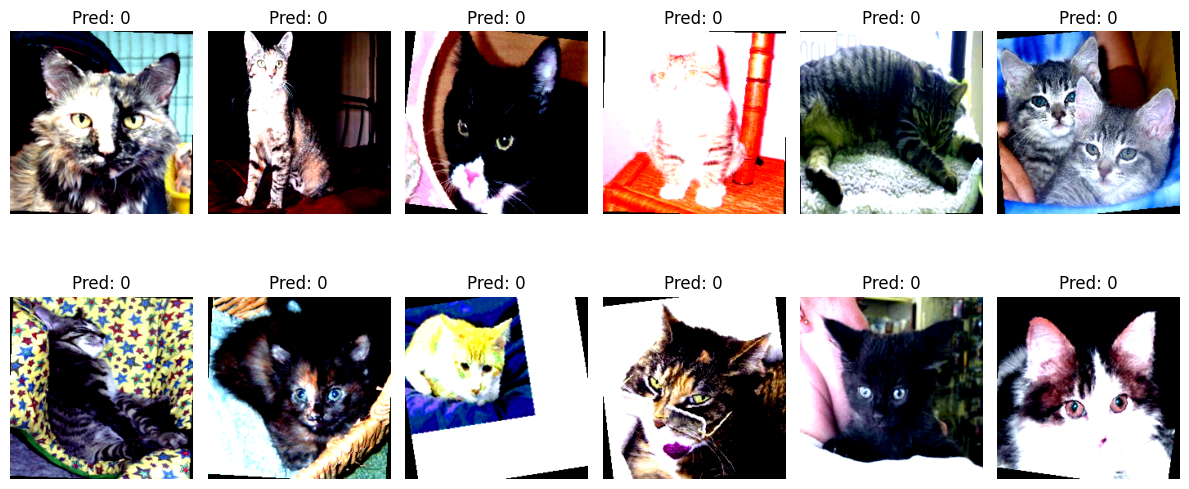

In [ ]:
train_losses,train_accs,test_losses,test_accs = [],[],[],[]


for epoch in range(1, 21):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Train Acc = {train_acc * 100:.2f} | Test Loss = {test_loss:.4f}, Test Acc = {test_acc * 100:.2f}")

visualize(model, test_loader, device=device, num_images=12)


In [ ]:
epochs = range(1,21)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs,train_losses,label = "train loss")
plt.plot(epochs,test_losses,label = "test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over epoch")
plt.legend()
plt.grid(True)

plt.subpplot(1,2,2)
plt.plot(epochs,train_accs,label = 'train acc')
plt.plot(epochs,test_accs,label = "test acc")
plt.xlabel("Epoch")
plt.ylabel("Acc")
plt.title("Acc over epoch")
plt.legend()
plt.grid(True)

plt.show()